### imports

In [ ]:
import pandas as pd
import numpy as np
import wfdb
import matplotlib.pyplot as plt
import ast
from preprocessing import *
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Bidirectional,
    LSTM,
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model


### Dataset Info - PTB XL

21799 total 
(9514 - NORM; 
5469 - MI)


12 leads

5 classes

Sample duration - 10 sec

Freq - 100 or 500 Hz

partitioned into 10 folders. "all records of a particular patient were assigned to the same fold"

### Loading dataset

In [14]:
tf.config.list_physical_devices("GPU")

[]

In [9]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

path_metadata = "C:\\Users\\Larissa\\bsi\\IC2025\\datasets\\ptbxl\\ptbxl_database.csv"
sampling_rate = 100
main_path = "C:\\Users\\Larissa\\bsi\\IC2025\\datasets\\ptbxl\\" #\\records"+str(sampling_rate)

In [10]:
pd.read_csv()

TypeError: read_csv() missing 1 required positional argument: 'filepath_or_buffer'

In [11]:
#loadidng metadata
metadata_all_df = pd.read_csv(path_metadata, index_col='ecg_id')
metadata_all_df.scp_codes = metadata_all_df.scp_codes.apply(lambda x: ast.literal_eval(x))

In [12]:
#loading raw signal data
ecg_data = load_raw_data(metadata_all_df, sampling_rate, main_path)

In [13]:
print(ecg_data[1].shape)
print("12 leads & 1000 points from each lead(?)")

(1000, 12)
12 leads & 1000 points from each lead(?)


In [14]:
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(main_path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

In [15]:
def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))


In [16]:
# Apply diagnostic superclass
metadata_all_df['diagnostic_superclass'] = metadata_all_df.scp_codes.apply(aggregate_diagnostic)

##### visualizing a few signals

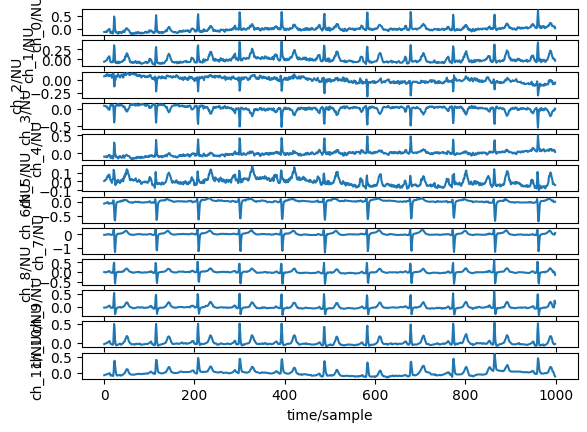

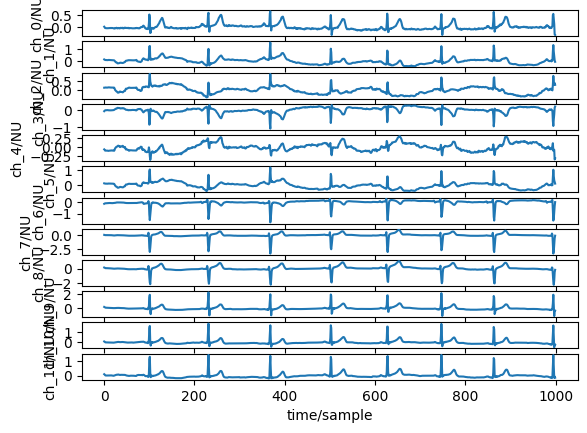

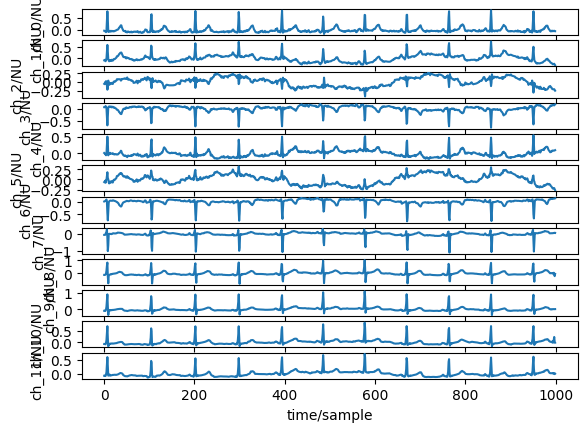

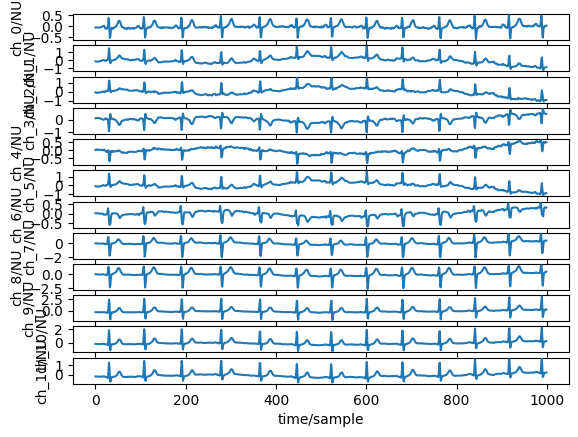

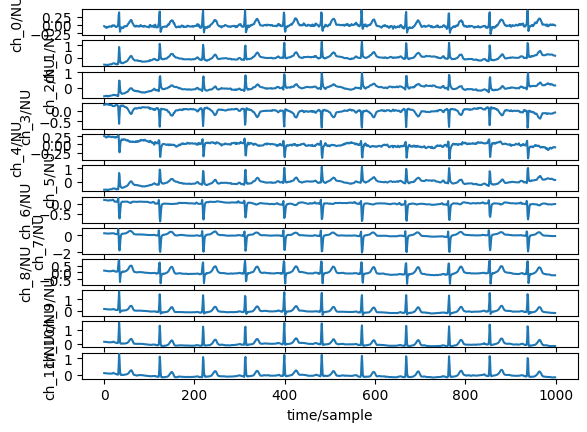

In [ ]:
for i in range(5):
    wfdb.plot.plot_items(signal=ecg_data[i])


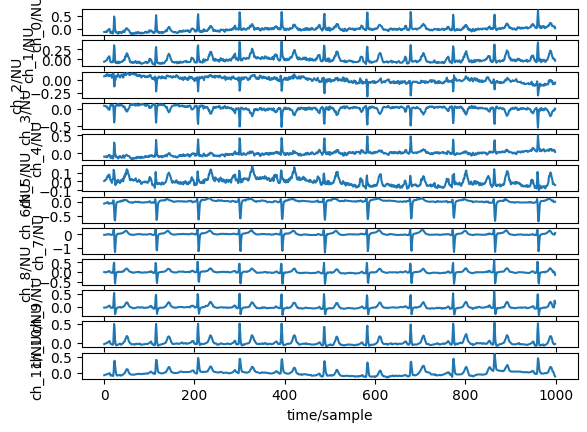

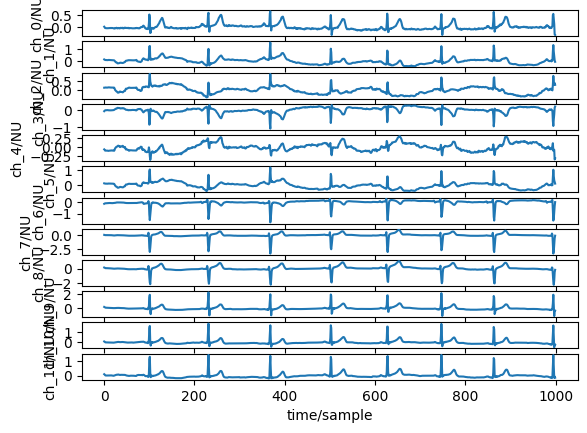

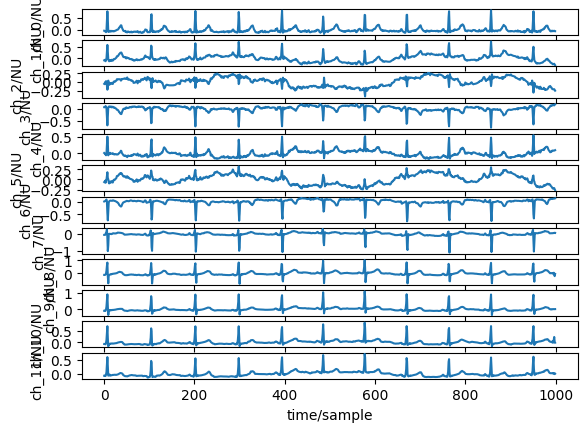

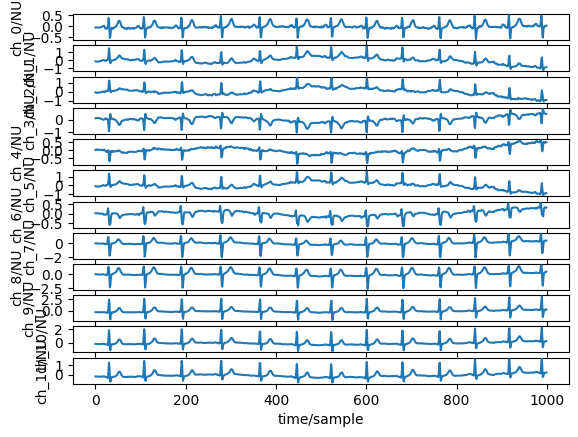

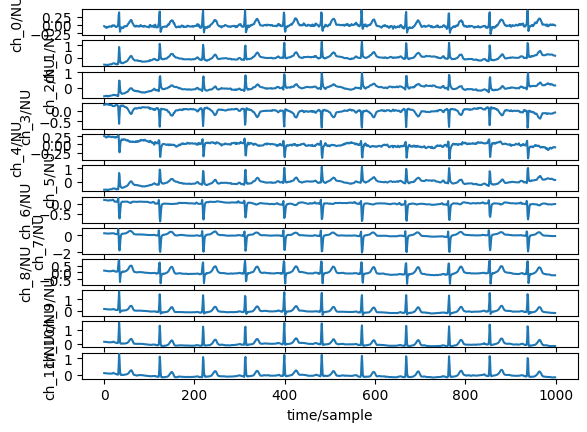

In [13]:
#loading 5 normal ecgs
for i in range(5):
    wfdb.plot.plot_items(signal=X_norm[i])


: 

: 

### Preprocessing


### splitting

In [17]:
import random

def split_ds(x, y, train_folds=7, val_folds=2, test_folds=1):

    folds = list(range(1, y["strat_fold"].max() + 1))
    random.shuffle(folds)

    train = folds[:train_folds]

    val = folds[
        train_folds :
        train_folds + val_folds
    ]

    test = folds[
        train_folds + val_folds :
    ]

    train_mask = y["strat_fold"].isin(train)
    val_mask = y["strat_fold"].isin(val)
    test_mask = y["strat_fold"].isin(test)

    return (
        (x[train_mask], y[train_mask]),
        (x[val_mask], y[val_mask]),
        (x[test_mask], y[test_mask]),
    )

In [18]:
mask = metadata_all_df["diagnostic_superclass"].isin([["NORM"], ["MI"]])

metadata = metadata_all_df[mask].copy()
X = ecg_data[mask]

metadata["label"] = (
    metadata["diagnostic_superclass"].apply(lambda x: x == ["MI"])
).astype(int)

train, val, test = split_ds(X, metadata)

raw_xtrain, ytrain = train
raw_xval, yval = val
raw_xtest, ytest = test

processed_xtrain = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xtrain
])

processed_xval = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xval
])

processed_xtest = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xtest
])

X_train, X_val, X_test, scaler = standardize_signals(
    processed_xtrain,
    processed_xval,
    processed_xtest
)

In [19]:
yval

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,diagnostic_superclass,label
ecg_id,,,,,,,,,,,,,,,,,,,,,
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM],0
9,18792.0,55.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-12-08 09:44:43,sinusrhythmus normales ekg,...,", I-AVR,",NaN,NaN,NaN,NaN,10,records100/00000/00009_lr,records500/00000/00009_hr,[NORM],0
11,11243.0,20.0,1,NaN,57.0,2.0,0.0,CS-12 E,1984-12-16 14:20:39,sinus arrhythmie sonst normales ekg,...,", I-AVL,",NaN,NaN,NaN,NaN,5,records100/00000/00011_lr,records500/00000/00011_hr,[NORM],0
38,17076.0,40.0,0,NaN,72.0,2.0,0.0,CS-12 E,1985-02-15 11:48:22,sinusrhythmus schwierig bestimmbare qrs-achse,...,", alles,",V5,NaN,NaN,NaN,10,records100/00000/00038_lr,records500/00000/00038_hr,[NORM],0
40,19501.0,60.0,0,NaN,85.0,2.0,0.0,CS-12 E,1985-02-20 11:43:45,sinusrhythmus linkstyp sonst normales ekg,...,NaN,NaN,NaN,NaN,NaN,10,records100/00000/00040_lr,records500/00000/00040_hr,[NORM],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21706,9079.0,67.0,0,NaN,NaN,0.0,0.0,CS100 3,2001-01-07 10:52:23,sinusrhythmus lagetyp normal periphere nieders...,...,NaN,NaN,NaN,NaN,NaN,5,records100/21000/21706_lr,records500/21000/21706_hr,[NORM],0
21709,19481.0,67.0,0,NaN,NaN,0.0,0.0,CS100 3,2001-01-08 09:50:54,sinusrhythmus linkstyp r-s Übergang in v ablei...,...,NaN,NaN,NaN,NaN,NaN,5,records100/21000/21709_lr,records500/21000/21709_hr,[MI],1
21809,12931.0,69.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-02-18 12:36:54,sinusrhythmus linkstyp qrs(t) abnorm inferi...,...,NaN,NaN,NaN,NaN,NaN,10,records100/21000/21809_lr,records500/21000/21809_hr,[NORM],0


## modelo

In [31]:
def create_model():
    model = Sequential([

    Input(shape=(1000, 12)),

    Bidirectional(
        LSTM(
            units=32,
            return_sequences=True
        )
    ),

    Bidirectional(
        LSTM(
            units=16,
            return_sequences=True
        )
    ),

    Bidirectional(
        LSTM(
            units=4,
            return_sequences=False
        )
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

    return model

In [ ]:
model = create_model()

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.F1Score(name="f1_score")
    ]
)

model.summary()

## callbacks ##
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

model_path = "..\models"
checkpoint = ModelCheckpoint(
    model_path,
    monitor="val_loss",
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode="auto",
    save_freq="epoch",
    initial_value_threshold=None,
)

# training
history = model.fit(
    X_train,
    ytrain['label'],
    validation_data=(X_val, yval['label']),
    epochs=50,
    batch_size=96,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_3 (Bidirectio  (None, 1000, 64)         11520     
 nal)                                                            
                                                                 
 bidirectional_4 (Bidirectio  (None, 1000, 32)         10368     
 nal)                                                            
                                                                 
 bidirectional_5 (Bidirectio  (None, 8)                1184      
 nal)                                                            
                                                                 
 dense_3 (Dense)             (None, 32)                288       
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                      

INFO:tensorflow:Assets written to: C:\Users\Larissa\bsi\IC2025\xai-heartattack-detection\models\assets


INFO:tensorflow:Assets written to: C:\Users\Larissa\bsi\IC2025\xai-heartattack-detection\models\assets


86/86 [==============================] - 713s 8s/step - loss: 0.5382 - accuracy: 0.7773 - precision: 0.1667 - recall: 0.0039 - auc: 0.5641 - val_loss: 0.4620 - val_accuracy: 0.7902 - val_precision: 1.0000 - val_recall: 0.0021 - val_auc: 0.7525
Epoch 2/50
86/86 [==============================] - ETA: 0s - loss: 0.4039 - accuracy: 0.8239 - precision: 0.7003 - recall: 0.3447 - auc: 0.8197
Epoch 2: val_loss improved from 0.46205 to 0.37683, saving model to C:\Users\Larissa\bsi\IC2025\xai-heartattack-detection\models


INFO:tensorflow:Assets written to: C:\Users\Larissa\bsi\IC2025\xai-heartattack-detection\models\assets


...

INFO:tensorflow:Assets written to: C:\Users\Larissa\bsi\IC2025\xai-heartattack-detection\models\assets


86/86 [==============================] - 3345s 39s/step - loss: 0.1916 - accuracy: 0.9251 - precision: 0.8710 - recall: 0.7732 - auc: 0.9623 - val_loss: 0.2398 - val_accuracy: 0.9003 - val_precision: 0.7949 - val_recall: 0.7089 - val_auc: 0.9396
Epoch 35/50
86/86 [==============================] - ETA: 0s - loss: 0.1892 - accuracy: 0.9243 - precision: 0.8805 - recall: 0.7575 - auc: 0.9631 
Epoch 35: val_loss did not improve from 0.23979
86/86 [==============================] - 3262s 38s/step - loss: 0.1892 - accuracy: 0.9243 - precision: 0.8805 - recall: 0.7575 - auc: 0.9631 - val_loss: 0.2428 - val_accuracy: 0.9025 - val_precision: 0.7780 - val_recall: 0.7505 - val_auc: 0.9382
Epoch 36/50
86/86 [==============================] - ETA: 0s - loss: 0.1870 - accuracy: 0.9260 - precision: 0.8806 - recall: 0.7665 - auc: 0.9640  
Epoch 36: val_loss improved from 0.23979 to 0.23264, saving model to C:\Users\Larissa\bsi\IC2025\xai-heartattack-detection\models


INFO:tensorflow:Assets written to: C:\Users\Larissa\bsi\IC2025\xai-heartattack-detection\models\assets


INFO:tensorflow:Assets written to: C:\Users\Larissa\bsi\IC2025\xai-heartattack-detection\models\assets


86/86 [==============================] - 7865s 92s/step - loss: 0.1870 - accuracy: 0.9260 - precision: 0.8806 - recall: 0.7665 - auc: 0.9640 - val_loss: 0.2326 - val_accuracy: 0.9038 - val_precision: 0.8071 - val_recall: 0.7131 - val_auc: 0.9423
Epoch 37/50
86/86 [==============================] - ETA: 0s - loss: 0.1834 - accuracy: 0.9267 - precision: 0.8921 - recall: 0.7575 - auc: 0.9653  
Epoch 37: val_loss did not improve from 0.23264
86/86 [==============================] - 13516s 159s/step - loss: 0.1834 - accuracy: 0.9267 - precision: 0.8921 - recall: 0.7575 - auc: 0.9653 - val_loss: 0.2461 - val_accuracy: 0.9043 - val_precision: 0.7964 - val_recall: 0.7318 - val_auc: 0.9391
Epoch 38/50
54/86 [=================>............] - ETA: 21:39 - loss: 0.1850 - accuracy: 0.9244 - precision: 0.8721 - recall: 0.7738 - auc: 0.9648

In [ ]:
model = load_model("..\models")

results = model.evaluate(
    X_test,
    ytest['label'],
    verbose=1
)

print("\nResultados:")
for nome, valor in zip(model.metrics_names, results):
    print(f"{nome}: {valor:.4f}")

In [ ]:
loss, acc, precis, recall, auc = model.evaluate(X_test, ytest['label'], batch_size=96)

13/13 [==============================] - 14s 657ms/step - loss: 0.1709 - accuracy: 0.9427 - precision: 0.8971 - recall: 0.7991 - auc: 0.9655


[0.17088733613491058,
 0.9427350163459778,
 0.8970588445663452,
 0.7991266250610352,
 0.9654552936553955]

In [ ]:
#############################
# PLOTAR MATRIZ DE CONFUSAO
#PRINTAR RESULTADOS (acc, precisao, recall, auc FALTA COLOCAR F1 E ESPECIFICIDADE)
# anotar hiperparametros
# plotar loss e acc ao longo do treinamento




In [26]:
#hiperparametros
LR = 0.001
BATCH_SIZE = 96
EPOCHS = 50
AUGMENTATION = False

In [32]:
result_df = pd.DataFrame({"model":[],
                          "aumento de dados":[],
                          "acc": [],
                          "recall": [],
                          "f1": [],
                          "auc":[],
                          "batchsize": [],
                          "epochs": [],
                          "lr": []})

In [ ]:
result_df.loc[len(result_df)] = ["baseline (cnn + bilstm)", AUGMENTATION, acc, recall, None, auc, BATCH_SIZE, 36, LR]

In [34]:
result_df

,model,aumento de dados,acc,recall,f1,auc,batchsize,epochs,lr
0,baseline (cnn + bilstm),False,0.942735,0.799127,None,0.965455,96,36,0.001


### tuning hyperparameters with RandomSearch